# Projet final : Analyse et visualisation de donnees

In [1]:
# importer les packages nécéssaire pour l'analyse
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

In [2]:
# Afficher le rendu des graphes dans le navigateur web par defaut pour un meilleur 
# rendu
pio.renderers.default = 'browser'

## 1. Exploration et Preparation (Pandas)

In [3]:
# importer les données
df = pd.read_csv('Dataset.csv')

# afficher un apercu du dataset
df.head()

,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [4]:
# verifier la dimension des donnees : nombre de lignes et de colonnes
df.shape

(2000, 8)

In [5]:
# afficher les infos des donnees : types des variables et valeurs non nulles
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ProductId             2000 non-null   object 
 1   ProductCategory       2000 non-null   object 
 2   ChannelId             2000 non-null   object 
 3   Amount                2000 non-null   float64
 4   Value                 2000 non-null   int64  
 5   TransactionStartTime  2000 non-null   object 
 6   PricingStrategy       2000 non-null   int64  
 7   FraudResult           2000 non-null   int64  
dtypes: float64(1), int64(3), object(4)
memory usage: 125.1+ KB


In [6]:
# verifier les valeurs manquantes avant la suite de l'analyse
df.isnull().sum()

ProductId               0
ProductCategory         0
ChannelId               0
Amount                  0
Value                   0
TransactionStartTime    0
PricingStrategy         0
FraudResult             0
dtype: int64

## 2. Nettoyage, manipulation et preparation des variables

In [7]:
# convertir la colonne de temps en format datetime
df['TransactionStartTime'] = pd.to_datetime(df['TransactionStartTime'])

# verifier le resultat apres conversion
df.head()

,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15 02:18:49+00:00,2,0
1,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15 02:19:08+00:00,2,0
2,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15 02:44:21+00:00,2,0
3,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15 03:32:55+00:00,2,0
4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15 03:34:21+00:00,2,0


In [8]:
# manipulation et preparation des variables temporelles
df['Date'] = df['TransactionStartTime'].dt.date
df['Hour'] = df['TransactionStartTime'].dt.hour
df['Day'] = df['TransactionStartTime'].dt.day
df['Month'] = df['TransactionStartTime'].dt.month

df.head()

,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult,Date,Hour,Day,Month
0,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15 02:18:49+00:00,2,0,2018-11-15,2,15,11
1,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15 02:19:08+00:00,2,0,2018-11-15,2,15,11
2,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15 02:44:21+00:00,2,0,2018-11-15,2,15,11
3,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15 03:32:55+00:00,2,0,2018-11-15,3,15,11
4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15 03:34:21+00:00,2,0,2018-11-15,3,15,11


In [9]:
# preparation de variables utiles pour l'analyse financiere
df['AmountAbs'] = df['Amount'].abs()
df['MargeBrute'] = df['Value'] - df['AmountAbs']
df['TauxRentabilite'] = (df['MargeBrute'] / df['AmountAbs'].replace(0, pd.NA)) * 100

df[['Amount', 'AmountAbs', 'Value', 'MargeBrute', 'TauxRentabilite']].head()

,Amount,AmountAbs,Value,MargeBrute,TauxRentabilite
0,1000.0,1000.0,1000,0.0,0.0
1,-20.0,20.0,20,0.0,0.0
2,500.0,500.0,500,0.0,0.0
3,20000.0,20000.0,21800,1800.0,9.0
4,-644.0,644.0,644,0.0,0.0


## 3. Analyse avec Pandas

In [10]:
# compter le nombre de transactions dans chaque categorie
df['ProductCategory'].value_counts()

ProductCategory
financial_services    1041
airtime                831
utility_bill            52
tv                      31
data_bundles            30
movies                  10
ticket                   4
transport                1
Name: count, dtype: int64

In [11]:
# compter le nombre de transactions par canal
df['ChannelId'].value_counts()

ChannelId
ChannelId_3    1152
ChannelId_2     811
ChannelId_1      19
ChannelId_5      18
Name: count, dtype: int64

In [12]:
# compter le nombre de transactions frauduleuses et non frauduleuses
df['FraudResult'].value_counts()

FraudResult
0    1994
1       6
Name: count, dtype: int64

In [13]:
# afficher les statistiques descriptives des principales variables quantitatives
df[['Amount', 'Value', 'AmountAbs', 'MargeBrute', 'TauxRentabilite']].describe()

,Amount,Value,AmountAbs,MargeBrute,TauxRentabilite
count,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,5913.507545,7154.24850,7092.492455,61.756045,0.574162
std,45054.442262,44938.27784,44883.863682,465.160413,4.375077
min,-60000.000000,8.00000,8.000000,0.000000,0.000000
25%,-50.000000,100.00000,100.000000,0.000000,0.000000
50%,900.000000,1000.00000,1000.000000,0.000000,0.000000
75%,2000.000000,3500.00000,3500.000000,0.000000,0.000000
max,800000.000000,800000.00000,800000.000000,9500.000000,123.000000


In [14]:
# calculer le taux de fraude par categorie
fraud_rate_category = df.groupby('ProductCategory')['FraudResult'].mean().sort_values(ascending=False)
fraud_rate_category

ProductCategory
financial_services    0.005764
airtime               0.000000
data_bundles          0.000000
movies                0.000000
ticket                0.000000
transport             0.000000
tv                    0.000000
utility_bill          0.000000
Name: FraudResult, dtype: float64

In [15]:
# calculer la valeur moyenne par categorie
df.groupby('ProductCategory')['Value'].mean().sort_values(ascending=False)

ProductCategory
transport             41000.000000
ticket                32500.000000
utility_bill          24269.211538
movies                10170.000000
financial_services     8459.642651
tv                     5998.064516
airtime                4468.555957
data_bundles           2266.666667
Name: Value, dtype: float64

In [16]:
# resumer les montants par strategie de prix
df.groupby('PricingStrategy')[['AmountAbs', 'Value', 'MargeBrute']].agg(['mean', 'sum', 'count']).round(2)

AmountAbs                        Value                 \
                      mean         sum count       mean      sum count   
PricingStrategy                                                          
0                301476.19  6331000.00    21  301476.19  6331000    21   
1                 12611.11   567500.00    45   13222.22   595000    45   
2                  3491.76  6026784.91  1726    3547.39  6122797  1726   
4                  6056.25  1259700.00   208    6056.25  1259700   208   

                MargeBrute                  
                      mean       sum count  
PricingStrategy                             
0                     0.00      0.00    21  
1                   611.11  27500.00    45  
2                    55.63  96012.09  1726  
4                     0.00      0.00   208

## 4. Analyse Graphique

In [17]:
# calculer le nombre de transactions par jour
transactions_per_day = df.groupby('Date').size()

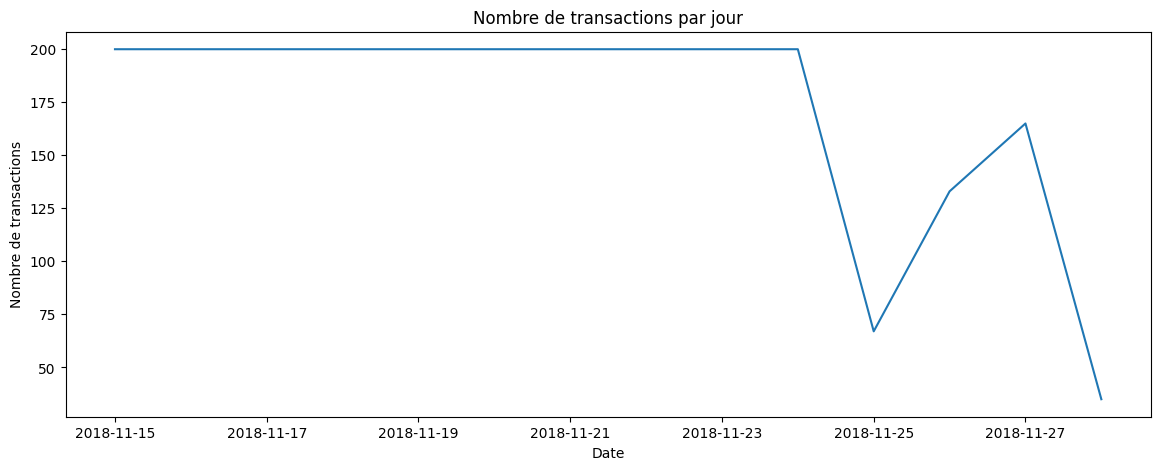

In [18]:
# graphique statique : evolution du nombre de transactions par jour
plt.figure(figsize=(14, 5))
transactions_per_day.plot()
plt.title('Nombre de transactions par jour')
plt.xlabel('Date')
plt.ylabel('Nombre de transactions')
plt.show()

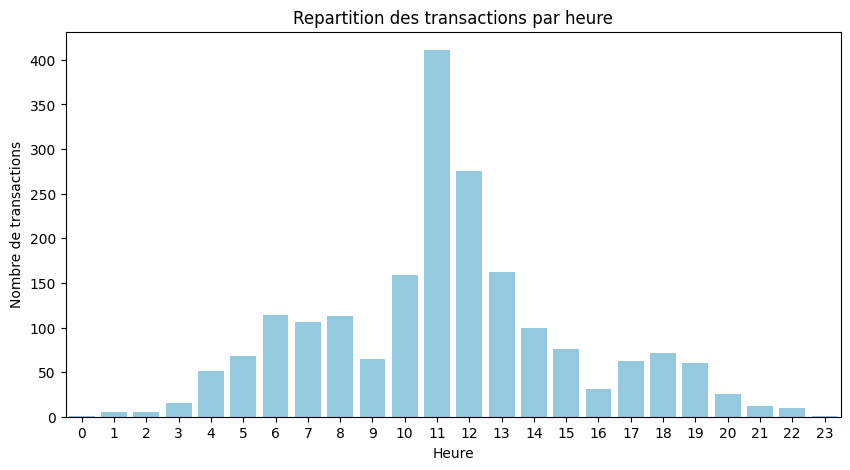

In [19]:
# graphique statique : repartition des transactions par heure
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Hour', color='skyblue')
plt.title('Repartition des transactions par heure')
plt.xlabel('Heure')
plt.ylabel('Nombre de transactions')
plt.show()

In [22]:
# preparer les donnees du graphique interactif par canal
channel_counts = df['ChannelId'].value_counts().reset_index()
channel_counts.columns = ['ChannelId', 'Count']

In [23]:
# graphique interactif : repartition des transactions par canal
fig = px.pie(channel_counts, names='ChannelId', values='Count',
             title='Repartition des transactions par canal')
fig.show(renderer='browser')

In [ ]:
# calculer le taux de rentabilite moyen par categorie
rentabilite = df.groupby('ProductCategory')['TauxRentabilite'].mean().sort_values()

In [ ]:
# graphique statique : taux de rentabilite moyen par categorie
plt.figure(figsize=(12, 5))
rentabilite.plot(kind='barh', color='teal')
plt.title('Taux de rentabilite moyen par categorie')
plt.xlabel('Taux de rentabilite')
plt.show()

In [ ]:
# graphique statique : heatmap des correlations (matrice de correlation)
plt.figure(figsize=(8, 5))
sns.heatmap(df[['Amount', 'Value', 'MargeBrute', 'TauxRentabilite', 'FraudResult']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlations entre variables')
plt.show()

In [25]:
# calculer le revenu total par categorie
revenue_per_category = df.groupby('ProductCategory')['Value'].sum().sort_values(ascending=False).reset_index()

In [26]:
# graphique interactif : revenu total par categorie de produit
fig = px.bar(revenue_per_category,
             x='ProductCategory', y='Value',
             title='Revenu total par categorie de produit',
             color='Value')
fig.show(renderer='browser')

In [27]:
# graphique interactif : taux de fraude par categorie
fraud_plot = df.groupby('ProductCategory')['FraudResult'].mean().sort_values(ascending=False).reset_index()
fraud_plot['FraudResult'] = fraud_plot['FraudResult'] * 100

fig = px.bar(fraud_plot, x='ProductCategory', y='FraudResult', color='FraudResult',
             title='Taux de fraude par categorie (%)')
fig.show(renderer='browser')

## 5. Conclusion

En resumant l'analyse :
- le dataset contient tres peu de fraudes,
- la categorie `financial_services` domine en volume,
- `ChannelId_3` et `ChannelId_2` concentrent l'essentiel des transactions,
- l'analyse graphique permet d'identifier des tendances et des correlations visuelles selon le temps, le canal et la categorie.